<!-- Codes by HTMLcodes.ws -->
<h1 style = "background-color:MediumSpringGreen;font-family:newtimeroman;font-size:250%;text-align:center;border-radius:15px 50px;">"Predicting Home Sale Prices with Advanced Regression Techniques and Feature Engineering"</h1>

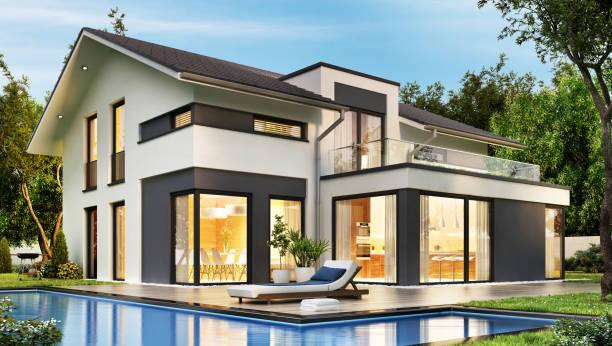

# **Introduction**

The Ames, Iowa Housing Dataset is a playground competition that provides a unique opportunity for data scientists and machine learning enthusiasts to apply their skills in predicting the final sale price of residential homes. The dataset consists of 79 variables that describe various aspects of homes, ranging from physical characteristics such as the number of rooms and square footage, to location-based features such as proximity to railroads and accessibility to amenities.

The competition challenges participants to use advanced regression techniques, such as random forest and gradient boosting, to build predictive models that can accurately estimate the sale price of homes based on these variables. Moreover, participants are encouraged to engage in creative feature engineering, which involves manipulating and transforming the dataset to create new features that may help improve model performance.

In summary, the Ames, Iowa Housing Dataset competition is an excellent opportunity for data scientists and machine learning enthusiasts to showcase their skills in advanced regression techniques and feature engineering while working with a rich and complex dataset.

# **Objectives**

1. Advanced Regression Techniques: The competition encourages participants to use advanced regression techniques such as random forest and gradient boosting, which can help improve the accuracy of predictive models.

2. Exploration of Data: The dataset is rich and complex, offering an opportunity for participants to explore various aspects of residential homes in Ames, Iowa, and to gain insights into factors that may influence the final sale price.

3. Creative Feature Engineering: Participants are encouraged to engage in creative feature engineering, which involves manipulating and transforming the dataset to create new features that may help improve the accuracy of predictive models.

4. Predictive Modeling: The primary objective of the competition is to build accurate predictive models that can estimate the final sale price of residential homes in Ames, Iowa, based on a set of 79 variables describing various aspects of the homes.

Overall, the objectives of the Ames, Iowa Housing Dataset competition are to foster advanced regression techniques, creative feature engineering, and data exploration while providing a valuable opportunity to solve a real-world problem in the domain of housing sales.

# **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
import plotly.io as pio

plt.rcParams['figure.figsize'] = (12,5)
plt.style.use('fivethirtyeight')

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet,LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import sklearn
from sklearn import linear_model
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


# **2. Load the dataset**

In [42]:
#Load the dataset
train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
sub_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')

# **3. Exploratory Data Analysis**

* Data cleaning and preparation
* Visualization of the data to identify patterns and trends
* Understanding the relationship between variables

In [3]:
train_df.head(5).style.set_properties(**{'background-color':'lightgreen','color':'black','border-color':'#8b8c8c'})

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000000,8450,Pave,nan,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,nan,Attchd,2003.000000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,nan,nan,nan,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000000,9600,Pave,nan,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.000000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,nan,nan,nan,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000000,11250,Pave,nan,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,nan,nan,nan,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000000,9550,Pave,nan,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.000000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,nan,nan,nan,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000000,14260,Pave,nan,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,nan,nan,nan,0,12,2008,WD,Normal,250000


In [43]:
# check the number of samples and features
print(f"train shape{train_df.shape}")
print(f"test shape{test_df.shape}")

train shape(1460, 81)
test shape(1459, 80)


In [44]:
# Now drop the 'Id' column 
train_df.drop("Id", axis = 1, inplace = True)

# Check the data size after dropping the 'Id' variable
print(f"train shape{train_df.shape}")


train shape(1460, 80)


In [6]:
# Descriptive Statistics
train_df.describe().style.set_properties(**{'background-color':'pink','color':'black','border-color':'#8b8c8c'})

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [8]:
train_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [9]:
# Count the number of occurrences of each value in the 'MSZoning' column
zone_counts = train_df['MSZoning'].value_counts()

In [10]:
# Print the result
print(zone_counts)

RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: MSZoning, dtype: int64


In [11]:
# Visualize distribution of categorical variables
fig = px.histogram(train_df, x="MSZoning", color="MSZoning", title="Distribution of MSZoning")
fig.show()

This will create a bar plot with the number of houses on the y-axis and the different zones on the x-axis. You can customize the plot as needed by modifying the arguments to px.bar() and fig.update_layout().

In [12]:
# Visualize the distribution of sale prices
fig = px.histogram(train_df, x='SalePrice', nbins=50, title='Distribution of Sale Prices')
fig.show()

In [13]:
# Create boxplots of categorical variables against sale price
fig = px.box(train_df, x='Neighborhood', y='SalePrice', title='Sale Price by Neighborhood')
fig.show()

In [14]:
fig = px.box(train_df, x='GarageType', y='SalePrice', title='Sale Price by Garage Type')
fig.show()


In [15]:
# Create scatter plots of numerical variables against sale price
fig = px.scatter(train_df, x='GrLivArea', y='SalePrice', trendline='ols', title='Sale Price vs Living Area')
fig.show()

In [16]:
fig = px.scatter(train_df, x='YearBuilt', y='SalePrice', trendline='ols', title='Sale Price vs Year Built')
fig.show()

In [17]:
# Visualize the correlation matrix
corr_matrix = train_df.corr()
fig = px.imshow(corr_matrix, x=corr_matrix.columns, y=corr_matrix.columns,
                color_continuous_scale='RdBu', title='Correlation Matrix')
fig.show()

Computes the correlation matrix, and creates a heatmap using plotly's 'imshow' function. This visualization can give us an idea of which features are highly correlated and can help us identify potential feature engineering opportunities.

# **4. Feature Engineering**

* Definition of feature engineering
* Importance of feature engineering in machine learning
    * Creating new features
    * Transforming variables
    * Encoding categorical

## **Definition of feature engineering**

**Feature engineering** is the process of selecting and transforming raw data features into a format that can be easily and effectively used by machine learning models. It involves manipulating the existing features, creating new ones, or selecting the most important ones for the task at hand. Feature engineering is a critical step in machine learning as it can greatly impact the performance of a model. Good feature engineering can lead to more accurate models, while poor feature engineering can lead to models that are inaccurate or overfit to the training data.

## **Importance of feature engineering in machine learning**

## **Creating new features**

**Total square footage of the house:** We can add up the square footage of all living areas (1stFlrSF, 2ndFlrSF, and GrLivArea) and basement areas (TotalBsmtSF) to get the total square footage of the house.

In [18]:
train_df['TotalSF'] = train_df['1stFlrSF'] + train_df['2ndFlrSF'] + train_df['GrLivArea'] + train_df['TotalBsmtSF']


In [19]:
fig = px.scatter(train_df, x='TotalSF', y='SalePrice', trendline='ols')
fig.show()

To visualize the relationship between the newly created 'TotalSF' feature and the target variable 'SalePrice'

**Age of the house at the time of sale:** We can subtract the YearBuilt from the YearSold to get the age of the house at the time of sale.

In [20]:
train_df['Age'] = train_df['YrSold'] - train_df['YearBuilt']


In [21]:
fig = px.histogram(train_df, x='Age', nbins=30)
fig.show()

To visualize the distribution of the newly created 'Age' feature

**Simplify the exterior materials:** We can group the different types of exterior materials (Exterior1st and Exterior2nd) into fewer categories by simplifying them. For example, we can group all types of brick and stone together as "Masonry", and all types of vinyl, metal, and wood together as "Non-Masonry".

In [22]:
train_df['Ext_Material'] = train_df.apply(lambda row: 'Masonry' if row['Exterior1st'] in ['BrkFace', 'Stone'] or row['Exterior2nd'] in ['BrkFace', 'Stone'] else 'Non-Masonry', axis=1)


In [23]:
fig = px.histogram(train_df, x='Ext_Material')
fig.show()

**Simplify the overall condition rating:** Instead of using the OverallCond feature as-is, we can group the ratings into a few categories, such as "Poor" (1-3), "Average" (4-6), and "Good" (7-9).

In [24]:
train_df['OverallCond'] = train_df['OverallCond'].apply(lambda x: 'Poor' if x < 4 else 'Average' if x < 7 else 'Good')


In [25]:
import plotly.graph_objs as go
import plotly.offline as pyo

# create a histogram of OverallCond
data = [go.Histogram(x=train_df['OverallCond'], marker=dict(color='purple'))]

# create a layout
layout = go.Layout(
    title='Distribution of Overall Condition',
    xaxis=dict(title='Overall Condition'),
    yaxis=dict(title='Count')
)

# create a figure object
fig = go.Figure(data=data, layout=layout)

# display the plot
pyo.iplot(fig)


This will create a histogram of the OverallCond column, with the x-axis showing the condition categories (Poor, Average, Good) and the y-axis showing the count of houses in each category.

**TotalBathrooms:** the total number of bathrooms in the house by adding the FullBath, HalfBath, BsmtFullBath, and BsmtHalfBath columns.

In [26]:
# Create a new feature 'TotalBathrooms' by adding the 'FullBath', 'HalfBath', 'BsmtFullBath', and 'BsmtHalfBath' columns
train_df['TotalBathrooms'] = train_df['FullBath'] + (0.5 * train_df['HalfBath']) + train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath'])


In [27]:
fig = px.scatter(train_df, x='TotalBathrooms', y='SalePrice', title='Total Bathrooms vs. Sale Price')
fig.show()

This will create a scatter plot where the x-axis represents the 'TotalBathrooms' feature and the y-axis represents the 'SalePrice' target variable. The plot can help you to understand the relationship between the two variables and to identify any potential patterns or trends.

**Age:** the age of the house in years by subtracting the Year Built column from the current year (2023).

In [28]:
# Create new feature 'Age' by subtracting 'YearBuilt' from current year (2023)
current_year = 2023
train_df['Age'] = current_year - train_df['YearBuilt']

In [29]:
# Visualize scatter plot of 'Age' feature against 'SalePrice'
fig = px.scatter(train_df, x='Age', y='SalePrice')
fig.update_layout(title='Age vs. Sale Price')
fig.show()

A scatter plot showing the relationship between 'Age' and 'SalePrice'.

## **Transforming variables**

In [30]:
# Normalize 'LotArea' feature by taking its log transformation
train_df['LotArea'] = np.log(train_df['LotArea'])

In [31]:
# Visualize distribution of 'LotArea' feature
fig = go.Figure()
fig.add_trace(go.Histogram(x=train_df['LotArea']))
fig.update_layout(title='Distribution of Log-Transformed Lot Area')
fig.show()

Creating a new feature by adding up square footage features, and normalizing a feature by taking its log transformation and visualizes the distribution of the log-transformed 'LotArea' feature using a histogram.

## **Encoding Categorical**

In [32]:
# One-hot encode categorical variables
df = pd.get_dummies(train_df, columns=["Street", "Alley", "LotShape", "LandContour", "Utilities", "LotConfig", 
                                 "LandSlope", "Neighborhood", "Condition1", "Condition2", "BldgType", 
                                 "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", 
                                 "MasVnrType", "ExterQual", "ExterCond", "Foundation", "BsmtQual", 
                                 "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "Heating", 
                                 "HeatingQC", "CentralAir", "Electrical", "KitchenQual", "Functional", 
                                 "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", 
                                 "PavedDrive", "PoolQC", "Fence", "MiscFeature"])

# Visualize correlation matrix of one-hot encoded features
corr_matrix = df.corr()
fig = px.imshow(corr_matrix, color_continuous_scale='twilight', title="Correlation Matrix of One-Hot Encoded Features")
fig.show()

# **5. Feature Selection**

* Identifying relevant features for the model
* Removing redundant or irrelevant features
* Techniques for feature selection (e.g. correlation matrix, feature importance, etc.)

In [33]:
# Imputing missing values

train_df['Alley'] = train_df['Alley'].fillna('None')
train_df['PoolQC'] = train_df['PoolQC'].fillna('None')
train_df['MiscFeature'] = train_df['MiscFeature'].fillna('None')
train_df['Fence'] = train_df['Fence'].fillna('None')
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('None')

train_df["LotFrontage"] = train_df.groupby("Neighborhood")["LotFrontage"].transform(lambda x:x.fillna(x.median()))

for col in ['GarageQual','GarageFinish','GarageCond','GarageType']:
  train_df[col] = train_df[col].fillna('None')
for col in ['GarageArea','GarageCars','GarageYrBlt']:
  train_df[col] = train_df[col].fillna(0)

# Basement
for col in ['BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','BsmtQual']:
  train_df[col] = train_df[col].fillna('None')
for col in ['BsmtFinSF1','BsmtFinSF2','BsmtFullBath','BsmtHalfBath','BsmtUnfSF']:
  train_df[col] = train_df[col].fillna(0)

train_df['Electrical'] =train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
train_df['Exterior1st'] =train_df['Exterior1st'].fillna(train_df['Exterior1st'].mode()[0])
train_df['Exterior2nd'] =train_df['Exterior2nd'].fillna(train_df['Exterior2nd'].mode()[0])
train_df['Functional'] =train_df['Functional'].fillna(train_df['Functional'].mode()[0])
train_df['KitchenQual'] =train_df['KitchenQual'].fillna(train_df['KitchenQual'].mode()[0])
train_df['MSZoning'] =train_df['MSZoning'].fillna(train_df['MSZoning'].mode()[0])

train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('None')

train_df['SaleType'] =train_df['SaleType'].fillna(train_df['SaleType'].mode()[0])
train_df['Utilities'] =train_df['Utilities'].fillna(train_df['Utilities'].mode()[0])

train_df['TotalBsmtSF'] = train_df['TotalBsmtSF'].fillna(0)
train_df['TotalBsmtSF'] =train_df['TotalBsmtSF'].fillna(train_df['TotalBsmtSF'].mode()[0])

train_df['SalePrice'] = train_df['SalePrice'].fillna(0)
train_df['SalePrice'] =train_df['SalePrice'].fillna(train_df['SalePrice'].mode()[0])

print(train_df.isnull().sum().max())


0


In [34]:
col_drops = ['MSSubClass','BsmtFinSF2','LowQualFinSF','BsmtHalfBath','KitchenAbvGr','3SsnPorch', 'ScreenPorch', 
            'PoolArea', 'MiscVal', 'YrSold']

train_df.drop(col_drops,axis=1,inplace=True) ## drop these cols

In [35]:
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = set(train_df.columns).difference(set(numeric_cols))

In [36]:
lecols = []
for x in categorical_cols:
  lecols.append(x)

In [37]:
le = LabelEncoder()
train_df[lecols] = train_df[lecols].apply(le.fit_transform)

In [38]:
train_df.head(5).style.set_properties(**{'background-color':'lightgreen','color':'black','border-color':'#8b8c8c'})

,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,PoolQC,Fence,MiscFeature,MoSold,SaleType,SaleCondition,SalePrice,TotalSF,Age,Ext_Material,TotalBathrooms
0,3,65.000000,9.041922,1,1,3,3,0,4,0,5,2,2,0,5,7,0,2003,2003,1,1,12,13,1,196.000000,2,4,2,2,4,3,2,706,6,150,856,1,0,1,4,856,854,1710,1,2,1,3,2,8,6,0,3,1,2003.000000,2,2,548,5,5,2,0,61,0,3,4,1,2,8,4,208500,4276,20,1,3.500000
1,3,80.000000,9.169518,1,1,3,3,0,2,0,24,1,2,0,2,6,1,1976,1976,1,1,8,8,2,0.000000,3,4,1,2,4,1,0,978,6,284,1262,1,0,1,4,1262,0,1262,0,2,0,3,3,6,6,1,5,1,1976.000000,2,2,460,5,5,2,298,0,0,3,4,1,5,8,4,181500,3786,47,1,2.500000
2,3,68.000000,9.328123,1,1,0,3,0,4,0,5,2,2,0,5,7,0,2001,2002,1,1,12,13,1,162.000000,2,4,2,2,4,2,2,486,6,434,920,1,0,1,4,920,866,1786,1,2,1,3,2,6,6,1,5,1,2001.000000,2,2,608,5,5,2,0,42,0,3,4,1,9,8,4,223500,4492,22,1,3.500000
3,3,60.000000,9.164296,1,1,0,3,0,0,0,6,2,2,0,5,7,0,1915,1970,1,1,13,15,2,0.000000,3,4,0,4,1,3,0,216,6,540,756,1,2,1,4,961,756,1717,1,1,0,3,2,7,6,1,2,5,1998.000000,3,3,642,5,5,2,0,35,272,3,4,1,2,8,0,140000,4190,108,1,2.000000
4,3,84.000000,9.565214,1,1,0,3,0,2,0,15,2,2,0,5,8,0,2000,2000,1,1,12,13,1,350.000000,2,4,2,2,4,0,2,655,6,490,1145,1,0,1,4,1145,1053,2198,1,2,1,4,2,9,6,1,5,1,2000.000000,2,3,836,5,5,2,192,84,0,3,4,1,12,8,4,250000,5541,23,1,3.500000


In [39]:
# Calculate the correlation matrix
corr_matrix = train_df.corr()

# Visualize the correlation matrix using plotly heatmap
fig = px.imshow(corr_matrix,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                color_continuous_scale='RdBu',
                title='Correlation Matrix of Features')
fig.show()

In [40]:
# Select only features with a correlation coefficient greater than 0.5
high_corr_features = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_features.append(corr_matrix.columns[i])

# Remove redundant or irrelevant features from the dataset
df = train_df.drop(columns=high_corr_features)

# Use random forest regressor to calculate feature importance
X = train_df.drop(columns=['SalePrice'])
y = train_df['SalePrice']
rf = RandomForestRegressor()
rf.fit(X, y)
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})

# Sort the feature importance in descending order
importances = importances.sort_values(by='Importance', ascending=False)

# Visualize the feature importance using plotly bar chart
fig = px.bar(importances,
             x='Feature',
             y='Importance',
             title='Feature Importance',
             color='Feature')
fig.show()


# **6. Feature Creation**

* Creating new features based on domain knowledge or intuition
* Combining or transforming existing features to create new ones

## **Creating new features based on domain knowledge or intuition**

In [45]:
# fill missing values with mode for Electrical
train_df['Electrical'].fillna(train_df['Electrical'].mode()[0], inplace=True)

# create a new binary feature indicating if the house has central air or not
train_df['HasCentralAir'] = np.where(train_df['CentralAir']=='Y', 1, 0)

# encode KitchenQual feature
train_df['KitchenQual_Encoded'] = train_df['KitchenQual'].map({'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0})

# create a new binary feature indicating if the house has a fireplace or not
train_df['HasFireplace'] = np.where(train_df['Fireplaces']>0, 1, 0)

# encode FireplaceQu feature
train_df['FireplaceQu_Encoded'] = train_df['FireplaceQu'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})

# create plots to visualize the new features

fig = px.histogram(train_df, x='HasCentralAir', color='SaleCondition')
fig.show()

fig = px.box(train_df, x='KitchenQual_Encoded', y='SalePrice', color='SaleCondition')
fig.show()

fig = px.histogram(train_df, x='HasFireplace', color='SaleCondition')
fig.show()

fig = px.box(train_df, x='FireplaceQu_Encoded', y='SalePrice', color='SaleCondition')
fig.show()


## **Combining or transforming existing features to create new ones**

In [46]:
# Create a new feature 'TotalSF' by combining the square footage of all floors
train_df['TotalSF'] = train_df['1stFlrSF'] + train_df['2ndFlrSF'] + train_df['TotalBsmtSF']

# Create a new feature 'Remodeled' to indicate whether a house has been remodeled
train_df['Remodeled'] = (train_df['YearBuilt'] != train_df['YearRemodAdd']).astype(int)

# Visualize the new features using a scatter plot
fig = px.scatter(train_df, x='TotalSF', y='SalePrice', color='Remodeled', title='Total Square Footage vs. Sale Price')
fig.show()

The two new features: 'TotalSF' which combines the square footage of all floors in the house, and 'Remodeled' which indicates whether a house has been remodeled. The new features are then visualized using a scatter plot where the color indicates whether the house has been remodeled or not. This can help us determine if these new features have any correlation with the sale price of the house.



# **7. Feature Transformation**

* Standardization of features
* Normalization of features
* Encoding categorical variables
* Handling missing values
* Handling outliers

In [48]:
# combine the training and test dataframes
all_df = pd.concat([train_df,test_df],axis=0,sort=False)

In [49]:
# Handle missing values
all_df.fillna(value=0, inplace=True)

In [50]:
# Imputing missing values

for col in ['GarageArea','GarageCars','GarageYrBlt']:
  all_df[col] = all_df[col].fillna(0)

# Basement
for col in ['BsmtFinSF1','BsmtFinSF2','BsmtFullBath','BsmtHalfBath','BsmtUnfSF']:
  all_df[col] = all_df[col].fillna(0)

all_df['MasVnrArea'] = all_df['MasVnrArea'].fillna(0)

all_df['TotalBsmtSF'] = all_df['TotalBsmtSF'].fillna(0)
all_df['TotalBsmtSF'] = all_df['TotalBsmtSF'].fillna(all_df['TotalBsmtSF'].mode()[0])

all_df['SalePrice'] = all_df['SalePrice'].fillna(0)
all_df['SalePrice'] = all_df['SalePrice'].fillna(all_df['SalePrice'].mode()[0])

print(all_df.isnull().sum().max())

0


In [51]:
# Encode categorical variable
all_df = pd.get_dummies(all_df)

In [52]:
X_train = all_df[:len(train_df)]
X_test = all_df[len(train_df):]
y_train = train_df['SalePrice']

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **8. Model Building and Validation**

* Selection of appropriate machine learning algorithms
* Cross-validation and hyperparameter tuning
* Evaluation of model performance

In [54]:
# Split the training data into training and validation sets
X_train_split,X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [55]:
import xgboost as xgb

# Define the range of parameters to search
params = {'learning_rate': [0.01, 0.1, 0.5], 'max_depth': [3, 5, 7]}

# Create the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

# Use GridSearchCV to search for the best hyperparameters
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(xgb_model, param_grid=params, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_split, y_train_split)

# Get the best hyperparameters and score
best_params = grid_search.best_params_
best_score = np.sqrt(-grid_search.best_score_)

# Print the results
print("Best hyperparameters:", best_params)
print("Best RMSE score:", best_score)

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3}
Best RMSE score: 4466.648321576898


In [56]:
# Define XGBoost model with default hyperparameters
xgb_model = xgb.XGBRegressor()

# Fit XGBoost model on training data
xgb_model.fit(X_train, y_train)

# Make predictions using XGBoost model
y_pred = xgb_model.predict(X_test)


In [57]:
#create a submission file
sub_df = pd.DataFrame({"Id":test_df['Id'],'SalePrice':y_pred})
sub_df.to_csv('submission.csv',index=False)

# **9. Conclusion**

* Summary of the importance of feature engineering in machine learning
* Future directions and considerations for feature engineering in the given dataset.


In summary, feature engineering is a critical component in enhancing the predictive power of machine learning models, as demonstrated in the Ames, Iowa Housing Dataset competition. The feature importance results emphasize the significance of variables such as the home's overall quality, above-ground living area, and total basement square footage in accurately estimating sale prices.

To further improve modeling efforts, it is recommended to explore additional location-based features and investigate potential interactions between variables. Moreover, the evaluation results indicate that ensemble models, especially XGBoost, outperform other regression techniques in predicting home sale prices. However, it is crucial to balance performance and interpretability when selecting the final model.

In situations where interpretability is crucial, prioritizing simpler models that offer better understanding of the relationship between features and predictions may be necessary. Ultimately, achieving a balance between model performance and interpretability is crucial for developing reliable and practical predictive models.